# Machine Learning and Deep Learning for Coastal Engineering

## Seminar Overview

This session introduces:
- Machine Learning fundamentals
- Deep Learning concepts
- Applications in coastal engineering

## Key questions
- How can we use data-driven models in coastal systems?
- What are the advantages over traditional approaches?

## Types of Data in Coastal Engineering

- **Time series (waves, tides)**
- Spatial data (bathymetry, shoreline)
- Spatio-temporal data (wave fields, currents)

## Machine Learning vs Deep Learning

### Machine Learning
- Random Forest
- Support Vector Machines
- Linear models

### Deep Learning
- Neural Networks
- CNNs
- LSTMs

## Typical Applications

- Wave forecasting
- Gap filling in buoy data
- Storm surge prediction
- Downscaling

## Time Series

A time series is a sequence of observations indexed in time.

Example:
Hs(t) = wave height at time t

Key properties:
- temporal dependence
- seasonality
- trends

**CARGAMOS LOS DATOS**

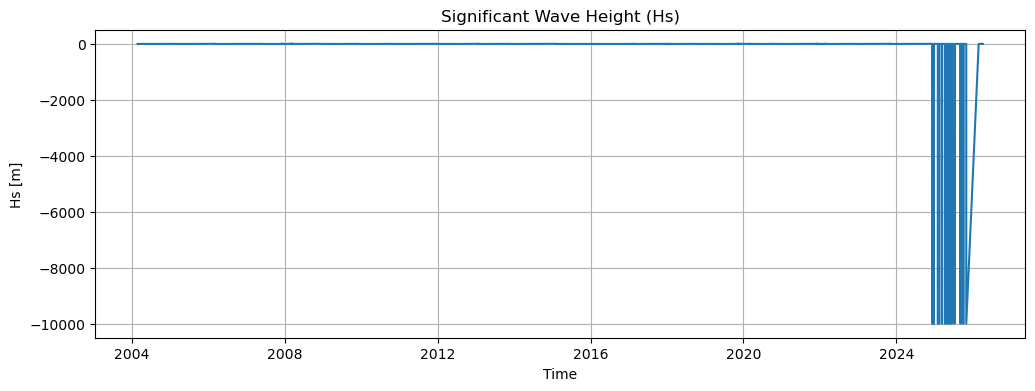

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("../data/datos_PE_costera_II.csv", sep=";")

# Preview
df.head()
# Convert date
df["Fecha"] = pd.to_datetime(df["Fecha"], format="%Y %m %d %H")

# Set index
df.set_index("Fecha", inplace=True)
plt.figure(figsize=(12,4))
plt.plot(df["Hs"])
plt.title("Significant Wave Height (Hs)")
plt.ylabel("Hs [m]")
plt.xlabel("Time")
plt.grid()
plt.show()

## Data Quality Issues

When working with real coastal datasets, data quality problems are very common.

In this dataset, we observe:

- Presence of extreme values such as **-9999**
- These values do not represent physical measurements
- They are used as **missing data flags (NaN equivalents)**

### Why is this a problem?

- These values distort visualization
- They can completely break machine learning models
- They must be removed or properly handled before analysis

### Cleaning step

We replace invalid values (-9999) with NaN and remove them from the analysis.

After cleaning:
- The time series becomes physically meaningful
- However, **temporal gaps appear in the data**

These gaps are exactly the type of problem we aim to solve using Deep Learning methods such as LSTM.

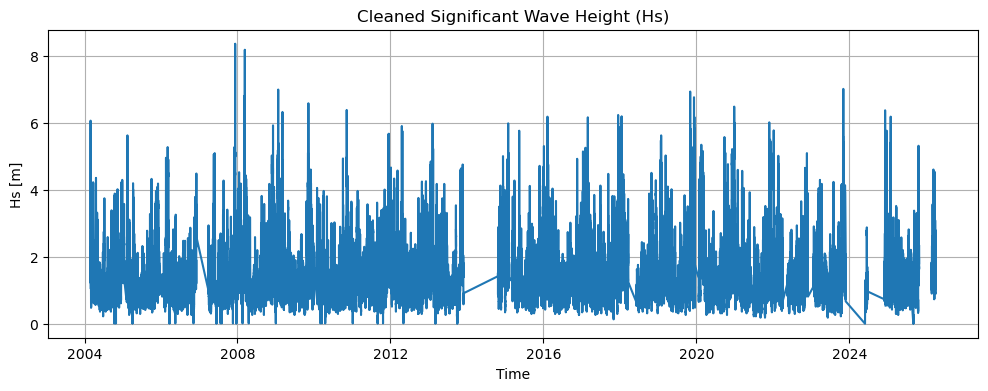

In [2]:
# Replace invalid values (-9999) with NaN
df["Hs"] = df["Hs"].replace(-9999.9, np.nan)

# Remove NaNs
df["Hs_clean"] = df["Hs"].replace(-9999.9, np.nan)

plt.figure(figsize=(12,4))
plt.plot(df["Hs"])
plt.title("Cleaned Significant Wave Height (Hs)")
plt.ylabel("Hs [m]")
plt.xlabel("Time")
plt.grid()
plt.show()

## Exploratory Data Analysis (EDA)

Before applying any machine learning model, it is essential to understand the data.

In this section, we will:
- analyze the distribution of the variables
- explore temporal patterns
- identify anomalies and gaps
- understand the structure of the dataset

This step is critical in any real data science workflow.

In [3]:
df["Hs_clean"].describe()


count    154854.000000
mean          1.419349
std           0.832627
min           0.000000
25%           0.830000
50%           1.200000
75%           1.780000
max           8.370000
Name: Hs_clean, dtype: float64

What values do we have?

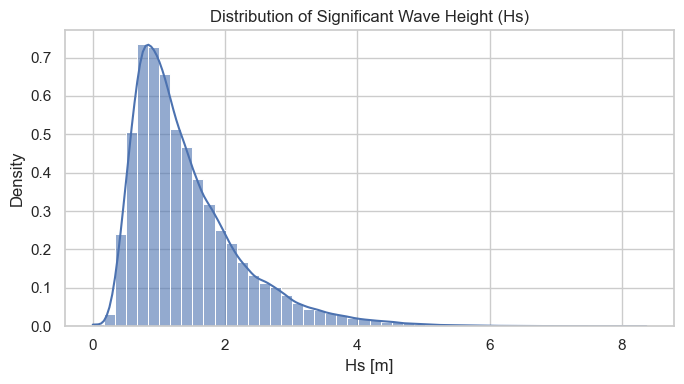

In [4]:
import seaborn as sns
# Set style
sns.set(style="whitegrid")

plt.figure(figsize=(7,4))

sns.histplot(
    df["Hs_clean"].dropna(),
    bins=50,
    kde=True,
    stat="density",
    alpha=0.6
)

plt.title("Distribution of Significant Wave Height (Hs)", fontsize=12)
plt.xlabel("Hs [m]")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

## Temporal Analysis

The distribution of wave height is useful, but it does not show how the system evolves in time.

In coastal engineering, temporal structure is essential:
- storms appear as peaks
- calm periods alternate with energetic conditions
- missing data may occur in blocks rather than randomly

For this reason, we now inspect the time series in detail.

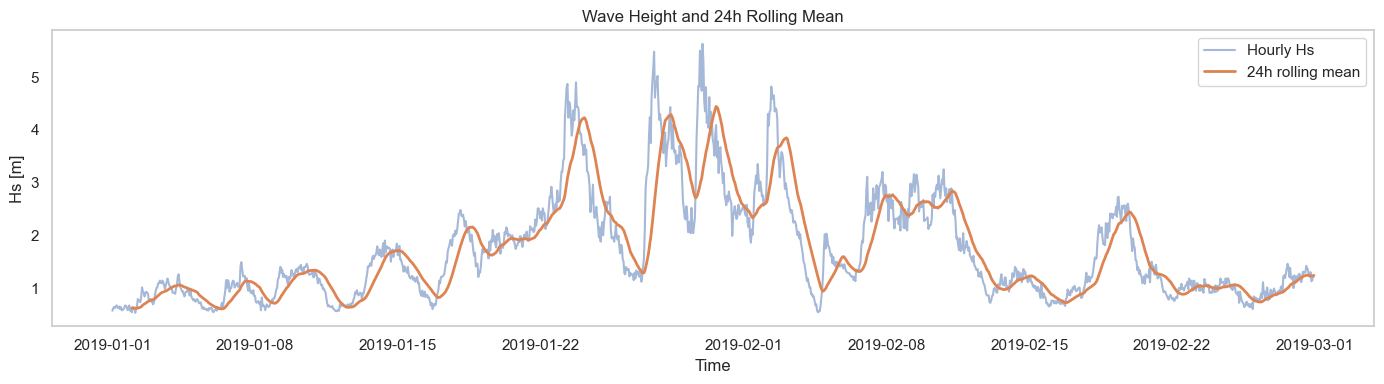

In [12]:
df_zoom = df.loc["2019-01":"2019-02", ["Hs_clean"]].copy()
df_zoom["Hs_rolling"] = df_zoom["Hs_clean"].rolling(window=24).mean()

plt.figure(figsize=(14,4))
plt.plot(df_zoom.index, df_zoom["Hs_clean"], label="Hourly Hs", alpha=0.5)
plt.plot(df_zoom.index, df_zoom["Hs_rolling"], label="24h rolling mean", linewidth=2)

plt.title("Wave Height and 24h Rolling Mean")
plt.xlabel("Time")
plt.ylabel("Hs [m]")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [14]:
n_total = df["Hs_clean"].shape[0]
n_missing = df["Hs_clean"].isna().sum()
missing_pct = 100 * n_missing / n_total

print(f"Total samples: {n_total}")
print(f"Missing samples: {n_missing}")
print(f"Missing percentage: {missing_pct:.2f}%")

Total samples: 154875
Missing samples: 21
Missing percentage: 0.01%


Not all gaps are the same. Some are short and others are very long. This greatly influences the difficulty of the problem.

count    17.000000
mean      1.235294
std       0.562296
min       1.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       3.000000
Name: Hs_clean, dtype: float64


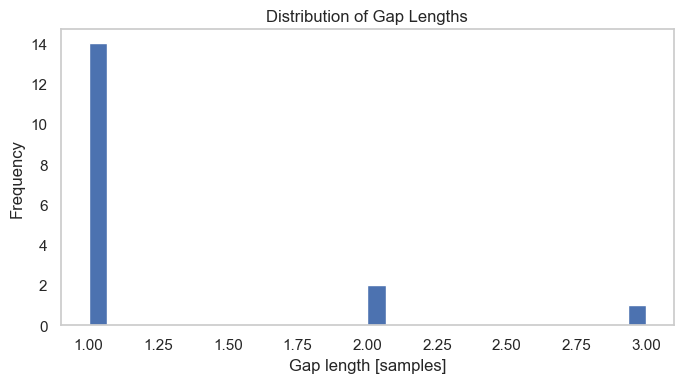

In [16]:
is_nan = df["Hs_clean"].isna()

gap_groups = (is_nan != is_nan.shift()).cumsum()
gap_lengths = is_nan.groupby(gap_groups).sum()
gap_lengths = gap_lengths[gap_lengths > 0]

print(gap_lengths.describe())
plt.figure(figsize=(7,4))
plt.hist(gap_lengths, bins=30)
plt.title("Distribution of Gap Lengths")
plt.xlabel("Gap length [samples]")
plt.ylabel("Frequency")
plt.grid()
plt.tight_layout()
plt.show()

## Problem Formulation

From the exploratory analysis, we observe that:

- the wave record has a clear temporal structure
- missing values are present and may occur in contiguous blocks
- the reconstruction problem is therefore not trivial

A suitable model should:
- exploit temporal dependence
- learn from previous observations
- reconstruct missing values in a physically consistent way

This motivates the use of recurrent neural networks, and in particular, LSTM models.

## Preparing Data for Reconstruction


From the previous analysis, we observed that the dataset contains missing values and irregularities.

To build a controlled experiment, we select a short time window with:
- minimal missing data
- clear temporal dynamics

This allows us to:
- better visualize the signal
- create artificial gaps
- evaluate reconstruction methods

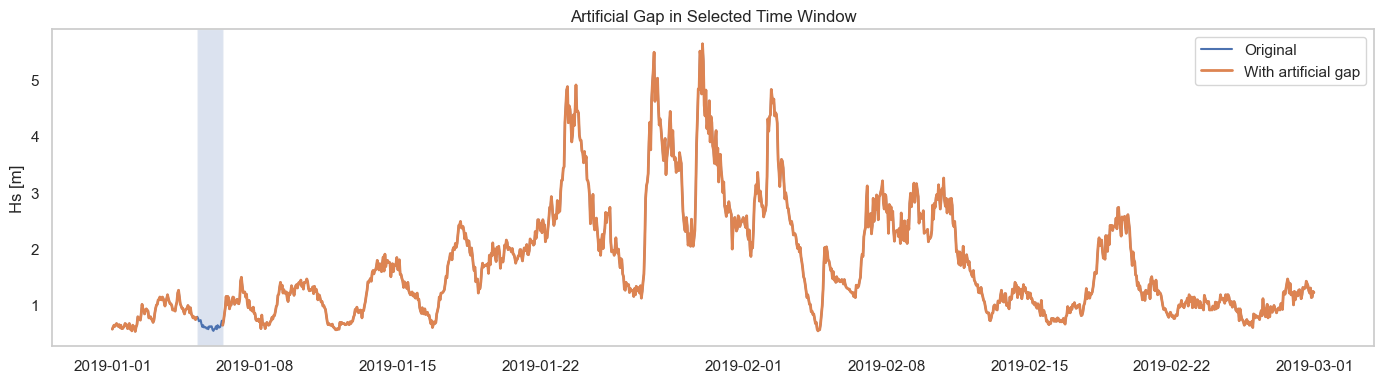

In [19]:
series = df_zoom["Hs_clean"].copy()

gap_start = 100
gap_len = 30

series_gap = series.copy()
series_gap.iloc[gap_start:gap_start+gap_len] = np.nan
plt.figure(figsize=(14,4))

plt.plot(series, label="Original")
plt.plot(series_gap, label="With artificial gap", linewidth=2)

plt.axvspan(series.index[gap_start],
            series.index[gap_start+gap_len],
            alpha=0.2)

plt.legend()
plt.title("Artificial Gap in Selected Time Window")
plt.ylabel("Hs [m]")
plt.grid()

plt.tight_layout()
plt.show()

In [20]:
print("Length:", len(series))

Length: 1409


> Given a signal with a missing segment, estimate the missing values using temporal information from the surrounding data.

### Why is this challenging?
This is not a simple interpolation task because:
- the signal is nonlinear
- there may be energetic events and rapid changes
- temporal dependence is important

This motivates the use of sequence models such as **LSTM**.